주택가격

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import pandas as pd
import io
housing = pd.read_csv(io.StringIO(uploaded['housing.csv'].decode('utf-8')))
housing.head()

In [ ]:
housing.info()

In [ ]:
housing["ocean_proximity"].value_counts()

In [ ]:
housing.describe()

In [ ]:
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)
train_set.head()

In [ ]:
housing["median_income"].hist()

In [ ]:
import pandas as pd
import numpy as np
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0, 1.5, 3.0, 4.5, 6, np.inf],
                               labels=[1,2,3,4,5])

In [ ]:
housing["income_cat"].value_counts()

In [ ]:
housing["income_cat"].hist()

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
  strat_train_set = housing.loc[train_index]
  strat_test_set = housing.loc[test_index]

In [ ]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

In [ ]:
housing["income_cat"].value_counts() / len(housing)

In [ ]:
def income_cat_proportions(data):
  return data["income_cat"].value_counts() / len(data)

trian_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(housing),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()

compare_props["Rand. %error"] = 100 * compare_props["Random"] / compare_props["Overall"] - 100
compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100


In [ ]:
compare_props

In [ ]:
for set_ in (strat_train_set, strat_test_set):
  set_.drop("income_cat", axis=1, inplace=True)

In [ ]:
housing = strat_train_set.copy()

housing.plot(kind="scatter", x="longitude", y="latitude")
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
             s=housing["population"]/100, label="population", figsize=(10,7),
             c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
             sharex=False)
plt.legend

In [ ]:
corr_matrix = housing.corr()
print(corr_matrix)

In [ ]:
corr_matrix["median_house_value"].sort_values(ascending=True)

In [ ]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms","housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12,8))

In [ ]:
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1)
plt.axis([0, 16, 0, 550000])

In [ ]:
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_per_rooms"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_household"]=housing["population"]/housing["households"]
print(housing)

In [ ]:
corr_matrix = housing.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

In [ ]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels  = strat_train_set["median_house_value"].copy()
housing.head()

In [ ]:
housing_labels.head()

In [ ]:
housing.info()

In [ ]:
sample_incomplete_rooms = housing[housing.isnull().any(axis=1)].head()
sample_incomplete_rooms

In [ ]:
sample_incomplete_rooms.dropna(subset=["total_bedrooms"])

In [ ]:
sample_incomplete_rooms.drop("total_bedrooms", axis=1)

In [ ]:
median = housing["total_bedrooms"].median()
sample_incomplete_rooms["total_bedrooms"].fillna(median, inplace=True)

In [ ]:
sample_incomplete_rooms

In [ ]:
from sklearn.impute import SimpleImputer
Imputer = SimpleImputer(strategy="median")

In [ ]:
housing_num = housing.drop("ocean_proximity", axis=1)
housing_num.head()

In [ ]:
Imputer.fit(housing_num)

In [ ]:
Imputer.statistics_

In [ ]:
housing_num.median().values

In [ ]:
x = Imputer.transform(housing_num)

In [ ]:
housing_tr = pd.DataFrame(x, columns = housing_num.columns, index=housing_num.index)

In [ ]:
housing_tr.loc[sample_incomplete_rooms.index.values]

In [ ]:
Imputer.strategy

In [ ]:
housing_tr.head()

In [ ]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(10)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:10]

In [ ]:
ordinal_encoder.categories_

In [ ]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

In [ ]:
housing_cat_1hot.toarray()

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True): # *args 또는 **kargs 없음
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self  # 아무것도 하지 않습니다
    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household,
                         bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attr_adder.transform(housing.to_numpy())

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ('Imputer', SimpleImputer(strategy="median")),
    ('attribs_adder', CombinedAttributesAdder()),
    ('std_scaler', StandardScaler()),
])

housing_num_tr = num_pipeline.fit_transform(housing_num)

In [ ]:
housing_num_tr

In [ ]:
from sklearn.compose import ColumnTransformer
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])
housing_prepared = full_pipeline.fit_transform(housing)

In [ ]:
housing_prepared

In [ ]:
housing_prepared.shape

In [ ]:
housing_prepared[0:3,]

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

In [ ]:
lin_reg.coef_

이미지분류

In [ ]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
mnist.keys()

In [ ]:
x,y = mnist["data"], mnist["target"]
print(x.shape)
print(y.shape)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
some_digit = x[0]
some_digit_image = some_digit.reshape(28,28)
plt.imshow(some_digit_image, cmap=mpl.cm.binary)
plt.show()

In [ ]:
import numpy as np
print(y[0:10])
y= y.astype(np.uint8)
print(y[0:10])

In [ ]:
x_train, x_test, y_train, y_test = x[:60000], x[60000:],y[:60000], y[60000:],

In [ ]:
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)
print(y_train_5)
print(y_test_5)
print(y_train_5.shape)
print(y_test_5.shape)

In [ ]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
sgd_clf.fit(x_train, y_train_5)

In [ ]:
print(sgd_clf.score(x_train, y_train_5))
print(sgd_clf.score(x_test, y_test_5))

In [ ]:
sgd_clf.predict([some_digit])

In [ ]:
y_test_pred=sgd_clf.predict(x_test)

from sklearn.metrics import confusion_matrix
confusion_matrix(y_test_5, y_test_pred)

In [ ]:
from sklearn.metrics import f1_score
f1_score(y_test_5, y_test_pred)

텐서플로우 중 케라스 모델

In [32]:
from tensorflow import keras

(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()
print(train_input.shape, train_target.shape)
print(test_input.shape, test_target.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


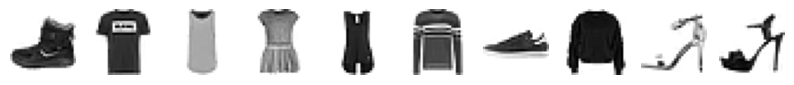

In [33]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1,10, figsize=(10,10))
for i in range(10):
  axs[i].imshow(train_input[i], cmap='gray_r')
  axs[i].axis('off')
plt.show()

In [34]:
import numpy as np

print([train_target[i] for i in range(10)])
print(np.unique(train_target, return_counts=True))

[9, 0, 0, 3, 0, 2, 7, 2, 5, 5]
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))


In [35]:
train_scaled = train_input / 255.0
train_scaled = train_scaled.reshape(-1, 28*28)

print(train_scaled.shape)

(60000, 784)


In [36]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(loss='log', max_iter=5, random_state=42)
scores = cross_validate(sc, train_scaled, train_target, n_jobs=-1)
print(np.mean(scores['test_score']))

0.8196000000000001


In [37]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)
print(train_scaled.shape, train_target.shape)
print(val_scaled.shape, val_target.shape)

dense = keras.layers.Dense(10, activation='softmax', input_shape=(784,))
model = keras.Sequential(dense)

(48000, 784) (48000,)
(12000, 784) (12000,)


In [38]:
model.compile(loss='sparse_categorical_crossentropy',
              metrics='accuracy')
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print(train_target[:10])

[7 3 5 8 6 9 3 3 9 9]


In [39]:
model.fit(train_scaled, train_target, epochs=5)
model.evaluate(val_scaled, val_target)

Epoch 1/5
1500/1500 [==============================] - 6s 4ms/step - loss: 0.6092 - accuracy: 0.7925
Epoch 2/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.4737 - accuracy: 0.8381
Epoch 3/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.4502 - accuracy: 0.8470
Epoch 4/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.4377 - accuracy: 0.8521
Epoch 5/5
375/375 [==============================] - 1s 2ms/step - loss: 0.4346 - accuracy: 0.8519


[0.4346103072166443, 0.8519166707992554]

In [40]:
dense1 = keras.layers.Dense(100, activation='sigmoid', input_shape=(784,))
dense2 = keras.layers.Dense(10, activation='softmax')

model = keras.Sequential([dense1, dense2])
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 100)               78500     
                                                                 
 dense_10 (Dense)            (None, 10)                1010      
                                                                 
Total params: 79510 (310.59 KB)
Trainable params: 79510 (310.59 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [47]:
model = keras.Sequential([
    keras.layers.Dense(100, activation='sigmoid', input_shape=(784,),
                       name='hidden'),
    keras.layers.Dense(10, activation='softmax', name='output')
], name='패션 MNIST모델')

In [48]:
model.summary()

Model: "패션 MNIST모델"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 hidden (Dense)              (None, 100)               78500     
                                                                 
 output (Dense)              (None, 10)                1010      
                                                                 
Total params: 79510 (310.59 KB)
Trainable params: 79510 (310.59 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [49]:
model = keras.Sequential()
model.add(keras.layers.Dense(100, activation='sigmoid', input_shape=(784,)))
model.add(keras.layers.Dense(10, activation='softmax'))

In [50]:
model.compile(loss='sparse_categorical_crossentropy', metrics='accuracy')
model.fit(train_scaled, train_target, epochs=5)
model.summary()

Epoch 1/5
1500/1500 [==============================] - 5s 3ms/step - loss: 0.5742 - accuracy: 0.8042
Epoch 2/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.4148 - accuracy: 0.8517
Epoch 3/5
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3790 - accuracy: 0.8629
Epoch 4/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.3567 - accuracy: 0.8711
Epoch 5/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.3374 - accuracy: 0.8768
Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_15 (Dense)            (None, 100)               78500     
                                                                 
 dense_16 (Dense)            (None, 10)                1010      
                                                                 
Total params: 79510 (310.59 KB)
Trainable params: 79510 (310.59 KB)
Non-train

In [52]:
model = keras.Sequential()
model.add(keras.layers.Flatten(input_shape=(28,28)))
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

In [53]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

train_scaled = train_input / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

In [54]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 [==============================] - 5s 3ms/step - loss: 0.5374 - accuracy: 0.8106
Epoch 2/5
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3967 - accuracy: 0.8590
Epoch 3/5
1500/1500 [==============================] - 5s 4ms/step - loss: 0.3576 - accuracy: 0.8701
Epoch 4/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.3354 - accuracy: 0.8790
Epoch 5/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.3213 - accuracy: 0.8849


In [55]:
model.evaluate(val_scaled, val_target)

375/375 [==============================] - 1s 2ms/step - loss: 0.3676 - accuracy: 0.8763


[0.3676303029060364, 0.8762500286102295]

In [56]:
sgd = keras.optimizers.SGD()
sgd = keras.optimizers.SGD(learning_rate=0.1)
sgd = keras.optimizers.SGD(momentum=0.9, nesterov=True)

model.compile(optimizer='sgd', loss = 'sparse_categorical_crossentropy',
              metrics='accuracy')
model.fit(train_scaled, train_target, epochs=5)

model.evaluate(val_scaled, val_target)

Epoch 1/5
1500/1500 [==============================] - 5s 3ms/step - loss: 0.2635 - accuracy: 0.9054
Epoch 2/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.2555 - accuracy: 0.9075
Epoch 3/5
1500/1500 [==============================] - 5s 4ms/step - loss: 0.2525 - accuracy: 0.9085
Epoch 4/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.2498 - accuracy: 0.9090
Epoch 5/5
375/375 [==============================] - 1s 2ms/step - loss: 0.3147 - accuracy: 0.8897


[0.3147324323654175, 0.8896666765213013]

In [57]:
model.compile(optimizer='Adagrad', loss = 'sparse_categorical_crossentropy',
              metrics='accuracy')
model.fit(train_scaled, train_target, epochs=5)

model.evaluate(val_scaled, val_target)

Epoch 1/5
1500/1500 [==============================] - 6s 3ms/step - loss: 0.2430 - accuracy: 0.9123
Epoch 2/5
1500/1500 [==============================] - 5s 3ms/step - loss: 0.2419 - accuracy: 0.9125
Epoch 3/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.2413 - accuracy: 0.9125
Epoch 4/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.2409 - accuracy: 0.9131
Epoch 5/5
375/375 [==============================] - 1s 3ms/step - loss: 0.3126 - accuracy: 0.8896


[0.3126215934753418, 0.8895833492279053]

In [58]:
model.compile(optimizer='RMSprop', loss = 'sparse_categorical_crossentropy',
              metrics='accuracy')
model.fit(train_scaled, train_target, epochs=5)

model.evaluate(val_scaled, val_target)

Epoch 1/5
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3008 - accuracy: 0.8924
Epoch 2/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.2943 - accuracy: 0.8950
Epoch 3/5
1500/1500 [==============================] - 5s 4ms/step - loss: 0.2851 - accuracy: 0.8989
Epoch 4/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.2787 - accuracy: 0.9018
Epoch 5/5
375/375 [==============================] - 1s 2ms/step - loss: 0.3754 - accuracy: 0.8758


[0.3753597140312195, 0.8757500052452087]

In [59]:
model.compile(optimizer='Adam', loss = 'sparse_categorical_crossentropy',
              metrics='accuracy')
model.fit(train_scaled, train_target, epochs=5)

model.evaluate(val_scaled, val_target)

Epoch 1/5
1500/1500 [==============================] - 6s 3ms/step - loss: 0.2640 - accuracy: 0.9043
Epoch 2/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.2490 - accuracy: 0.9096
Epoch 3/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.2378 - accuracy: 0.9122
Epoch 4/5
1500/1500 [==============================] - 5s 4ms/step - loss: 0.2310 - accuracy: 0.9141
Epoch 5/5
375/375 [==============================] - 1s 2ms/step - loss: 0.3465 - accuracy: 0.8859


[0.34648266434669495, 0.8859166502952576]

In [61]:
def model_fn(a_layer=None):
  model = keras.Sequential()
  model.add(keras.layers.Flatten(input_shape=(28, 28)))
  model.add(keras.layers.Dense(100, activation='relu'))
  if a_layer:
    model.add(a_layer)
    model.add(keras.layers.Dense(10, activation='softmax'))
  return model

model = model_fn()

model.summary()

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_4 (Flatten)         (None, 784)               0         
                                                                 
 dense_21 (Dense)            (None, 100)               78500     
                                                                 
Total params: 78500 (306.64 KB)
Trainable params: 78500 (306.64 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


dict_keys(['loss', 'accuracy'])


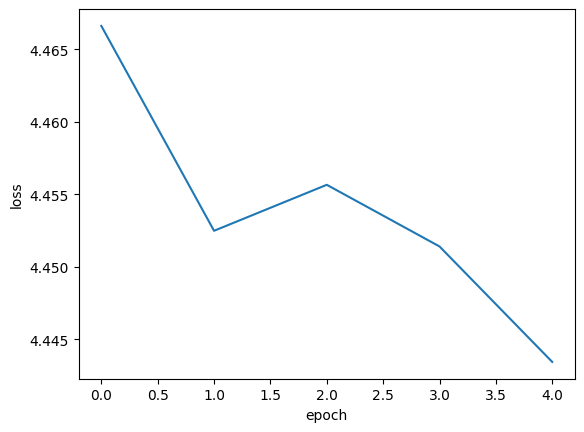

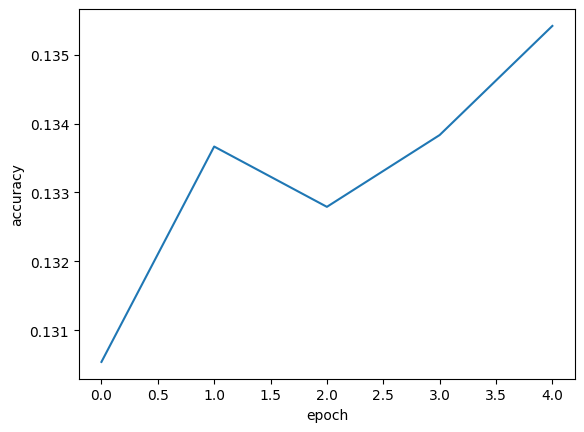

In [63]:
model.compile(loss='sparse_categorical_crossentropy', metrics='accuracy')
history = model.fit(train_scaled, train_target, epochs=5, verbose=0)
print(history.history.keys())

plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


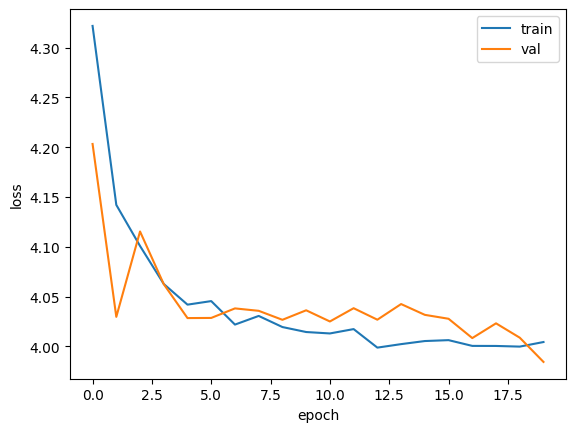

In [64]:
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics='accuracy')
history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))
print(history.history.keys())

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

Model: "sequential_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_6 (Flatten)         (None, 784)               0         
                                                                 
 dense_23 (Dense)            (None, 100)               78500     
                                                                 
 dropout (Dropout)           (None, 100)               0         
                                                                 
 dense_24 (Dense)            (None, 10)                1010      
                                                                 
Total params: 79510 (310.59 KB)
Trainable params: 79510 (310.59 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


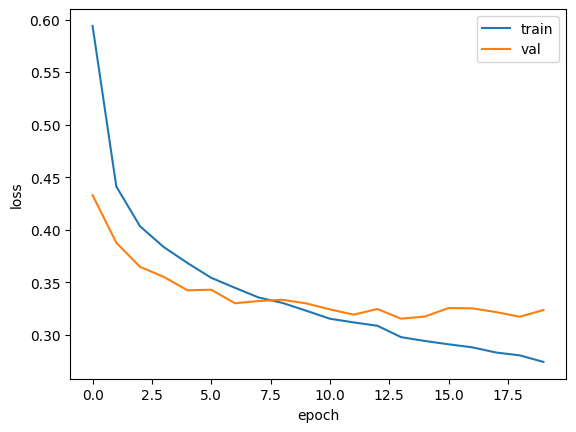

In [65]:
model = model_fn(keras.layers.Dropout(0.3))
model.summary()

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics='accuracy')
history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

실습 iris